<a href="https://colab.research.google.com/github/vad-source/AIMLROBOTICS/blob/main/SLAM/FASTSLAM_with_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AIMLROBOTICS
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

**Objective:**
>> To familiarize with the notion FAST SLAM with Deep Learning to aid the Data Association Problem

>> Assume a warehouse mobile robot is moving towards static goal using particle filtering based SLAM.

>> While navigating it localizises and builds feature based map using FAST SLAM.

>> **Note : The below code is a toy problem in which the data association is done only w.r.t best particle and all particles adopting the results to vary  the covariance. But students must convert this part as an exercise to apply the correspondence logic per particle and let them independently update the landmark EKF by self. **

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

#### Set up a simulation environment

In [ ]:
GRID_SIZE = 20
FIXED_GOAL = np.array([4.0, 4.0])
START_POS = np.array([17.0, 17.0])
NUM_PARTICLES = 5

LANDMARKS = np.array([
    [2, 2], [18, 2], [18, 18], [2, 18],
    [7, 10], [13, 10], [10, 6], [10, 14]
])
NUM_LANDMARKS = len(LANDMARKS)
R_measurement = np.diag([0.15**2, np.radians(3)**2])

#### Resolving Sensor Data Association using DL
* DL Classifier Setup:

* Input is [est_x, est_y, est_theta, range, bearing]

* Output class score per landmark

In [ ]:
class DataAssociationNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DataAssociationNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.network(x)

#### FASTSLAM using Particle Filter

In [ ]:
class FastSLAMParticle:
    def __init__(self):
        self.x = np.array([START_POS[0] + np.random.normal(0, 0.2),
                           START_POS[1] + np.random.normal(0, 0.2),
                           np.random.uniform(-np.pi, np.pi)])
        self.weight = 1.0 / NUM_PARTICLES
        self.history = [self.x[:2].copy()]

        self.lm_means = np.zeros((NUM_LANDMARKS, 2))
        self.lm_covs = np.zeros((NUM_LANDMARKS, 2, 2))
        self.lm_observed = np.zeros(NUM_LANDMARKS, dtype=bool)

    def predict(self, u, noise=0.1):
        self.x[0] += u[0] + np.random.normal(0, noise)
        self.x[1] += u[1] + np.random.normal(0, noise)
        self.x[2] += np.random.normal(0, 0.03)
        self.x[2] = (self.x[2] + np.pi) % (2 * np.pi) - np.pi
        self.history.append(self.x[:2].copy())

    def update(self, lm_idx, z):
        """ Classic EKF Update given an identified landmark ID """
        r_meas, b_meas = z[0], z[1]

        if not self.lm_observed[lm_idx]:
            lm_x = self.x[0] + r_meas * np.cos(self.x[2] + b_meas)
            lm_y = self.x[1] + r_meas * np.sin(self.x[2] + b_meas)
            self.lm_means[lm_idx] = [lm_x, lm_y]

            dx = lm_x - self.x[0]
            dy = lm_y - self.x[1]
            q = dx**2 + dy**2
            sq_q = np.sqrt(q)

            H_lm = np.array([[dx / sq_q, dy / sq_q], [-dy / q, dx / q]])
            H_lm_inv = np.linalg.inv(H_lm)

            self.lm_covs[lm_idx] = H_lm_inv @ R_measurement @ H_lm_inv.T
            self.lm_observed[lm_idx] = True
            self.weight *= 0.01
        else:
            mu = self.lm_means[lm_idx]
            Sigma = self.lm_covs[lm_idx]

            dx = mu[0] - self.x[0]
            dy = mu[1] - self.x[1]
            q = dx**2 + dy**2
            sq_q = np.sqrt(q)

            r_hat = sq_q
            b_hat = np.arctan2(dy, dx) - self.x[2]
            b_hat = (b_hat + np.pi) % (2 * np.pi) - np.pi
            z_hat = np.array([r_hat, b_hat])

            H_lm = np.array([[dx / sq_q, dy / sq_q], [-dy / q, dx / q]])
            Q = H_lm @ Sigma @ H_lm.T + R_measurement
            K = Sigma @ H_lm.T @ np.linalg.inv(Q)

            delta_z = np.array([r_meas, b_meas]) - z_hat
            delta_z[1] = (delta_z[1] + np.pi) % (2 * np.pi) - np.pi

            self.lm_means[lm_idx] += K @ delta_z
            self.lm_covs[lm_idx] = (np.eye(2) - K @ H_lm) @ Sigma

            num = np.exp(-0.5 * delta_z.T @ np.linalg.inv(Q) @ delta_z)
            den = 2.0 * np.pi * np.sqrt(np.linalg.det(Q))
            self.weight *= ((num / den) + 1e-5)

#### Warehouse Agent Process
* Includes simple range based sensor data collection

In [ ]:
class WarehouseEnv:
    def __init__(self):
        self.robot_pos = START_POS.copy()
        self.robot_theta = 0.0

    def get_raw_observations(self):
        """ Returns observations WITHOUT structural labels (Simulating unknown data association) """
        raw_obs = []
        for idx, lm in enumerate(LANDMARKS):
            dx = lm[0] - self.robot_pos[0]
            dy = lm[1] - self.robot_pos[1]
            r = np.sqrt(dx**2 + dy**2)
            if r < 12.0:
                b = np.arctan2(dy, dx) - self.robot_theta
                b = (b + np.pi) % (2 * np.pi) - np.pi
                r_noisy = r + np.random.normal(0, np.sqrt(R_measurement[0,0]))
                b_noisy = b + np.random.normal(0, np.sqrt(R_measurement[1,1]))
                # Returns (true_idx for training/validation metrics, and the noisy feature vector)
                raw_obs.append((idx, np.array([r_noisy, b_noisy])))
        return raw_obs

    def step(self, u):
        self.robot_pos += u
        return self.robot_pos, self.get_raw_observations()


#### Run the simulation and Plot the Observation

In [ ]:
def draw_covariance_ellipse(ax, mean, cov, color):
    try:
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        width, height = 2 * np.sqrt(np.maximum(vals, 1e-9))
        ell = Ellipse(xy=mean, width=width, height=height, angle=theta,
                      edgecolor=color, facecolor='none', linewidth=1.2, alpha=0.4)
        ax.add_patch(ell)
    except np.linalg.LinAlgError:
        pass


=================== STEP 00 ===================
True Robot Position: [16.47, 16.47]
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 2
    ↳ Particle 0 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 2 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 2
    ↳ Particle 0 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 2 (Updated existing map entry)
  [Measurement Dete

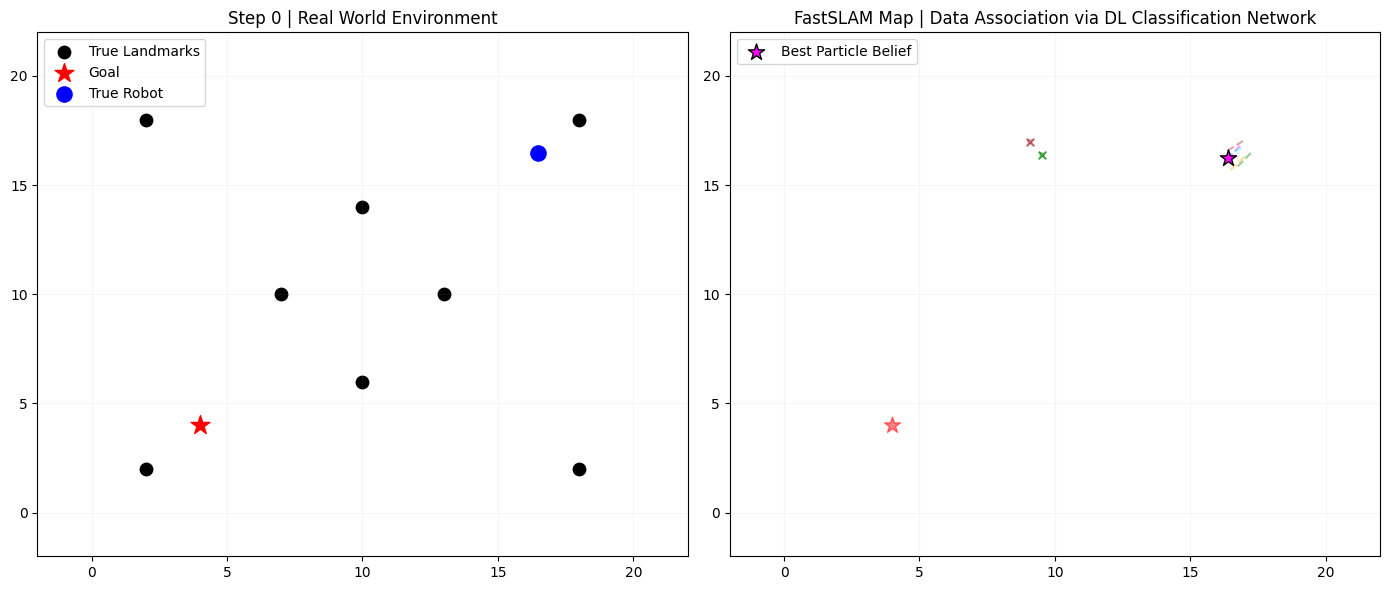


=================== STEP 01 ===================
True Robot Position: [15.94, 15.94]
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 2
    ↳ Particle 0 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 2 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Dete

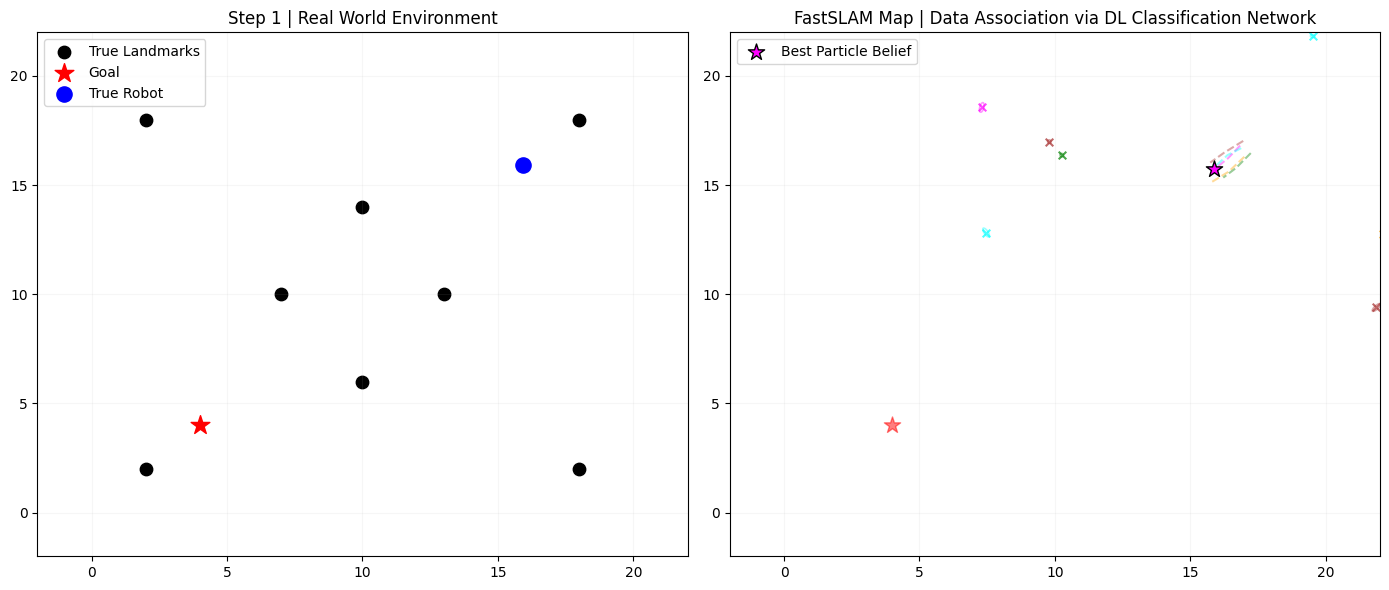


=================== STEP 02 ===================
True Robot Position: [15.40, 15.42]
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 2
    ↳ Particle 0 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 2 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 2 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Dete

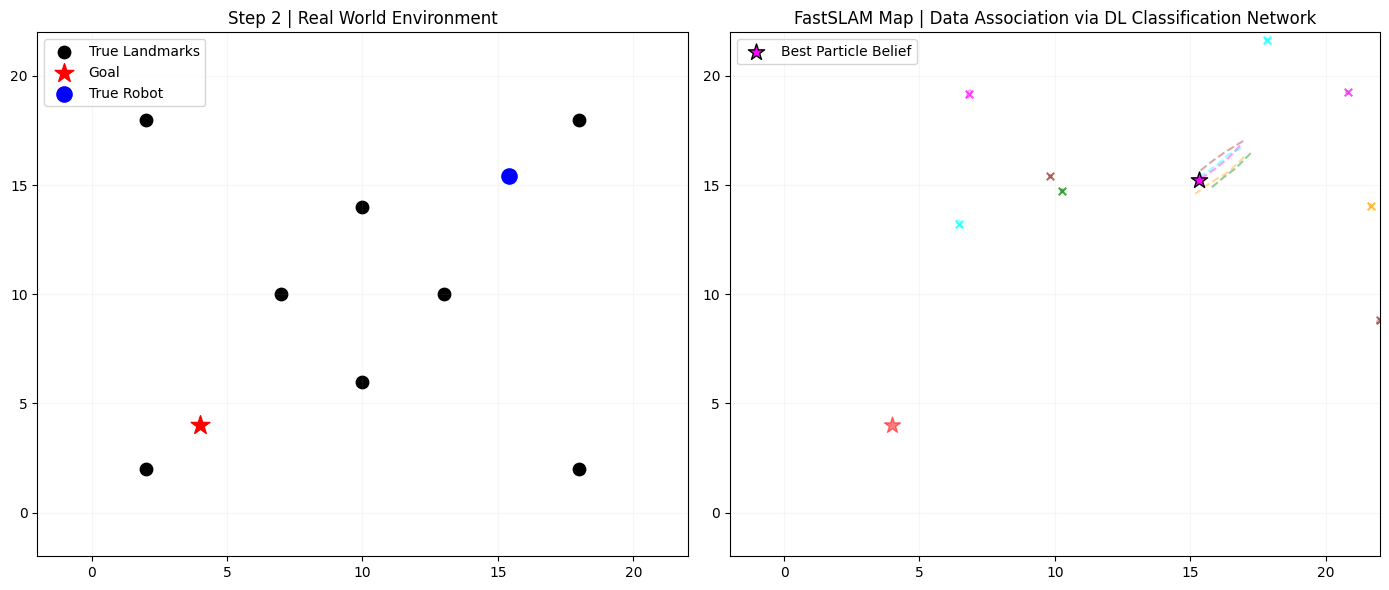


=================== STEP 03 ===================
True Robot Position: [14.87, 14.89]
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 7
    ↳ Particle 0 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 7 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Dete

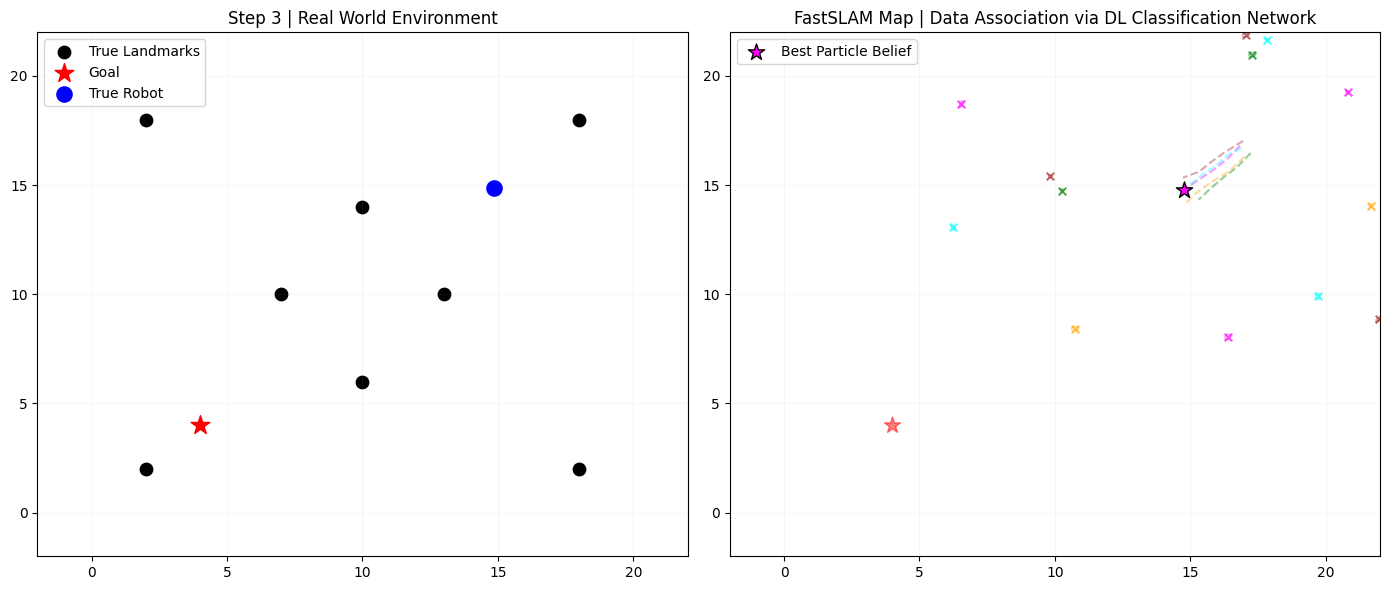


=================== STEP 04 ===================
True Robot Position: [14.34, 14.36]
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 7
    ↳ Particle 0 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 7 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Dete

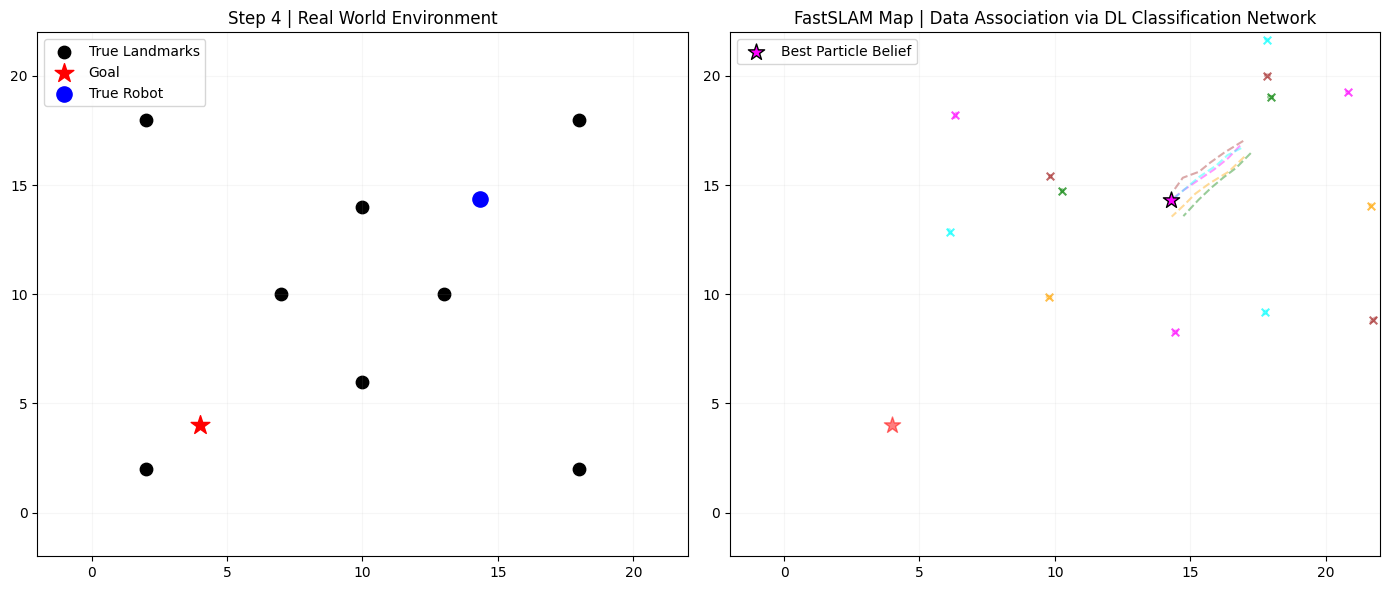


=================== STEP 05 ===================
True Robot Position: [13.81, 13.83]
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 7
    ↳ Particle 0 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 7 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 7 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Dete

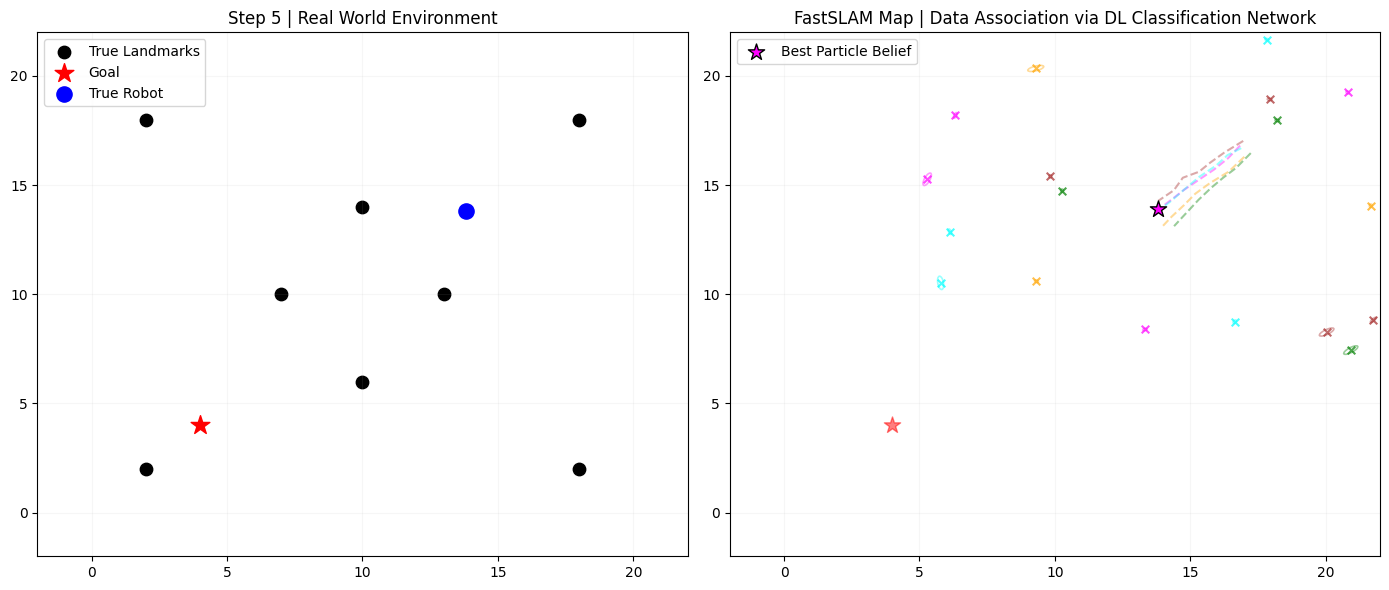


=================== STEP 06 ===================
True Robot Position: [13.28, 13.29]
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 5
    ↳ Particle 0 updated Landmark ID 5 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 5 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 5 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 5 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 5 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Dete

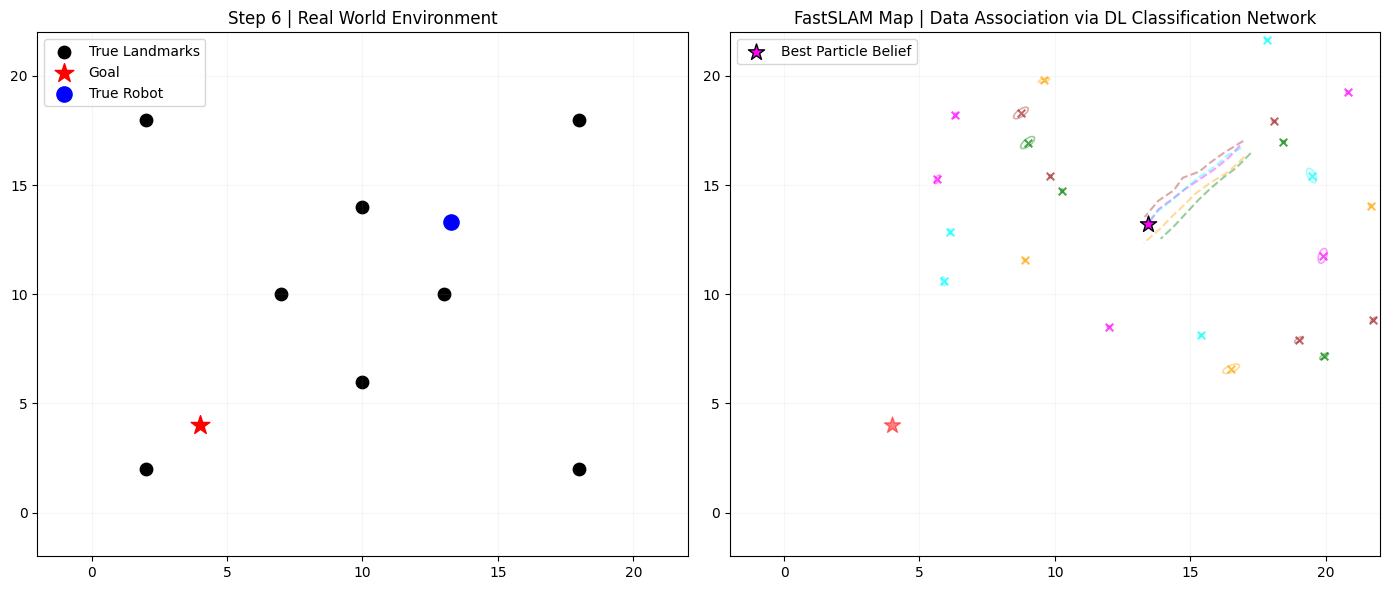


=================== STEP 07 ===================
True Robot Position: [12.75, 12.77]
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Dete

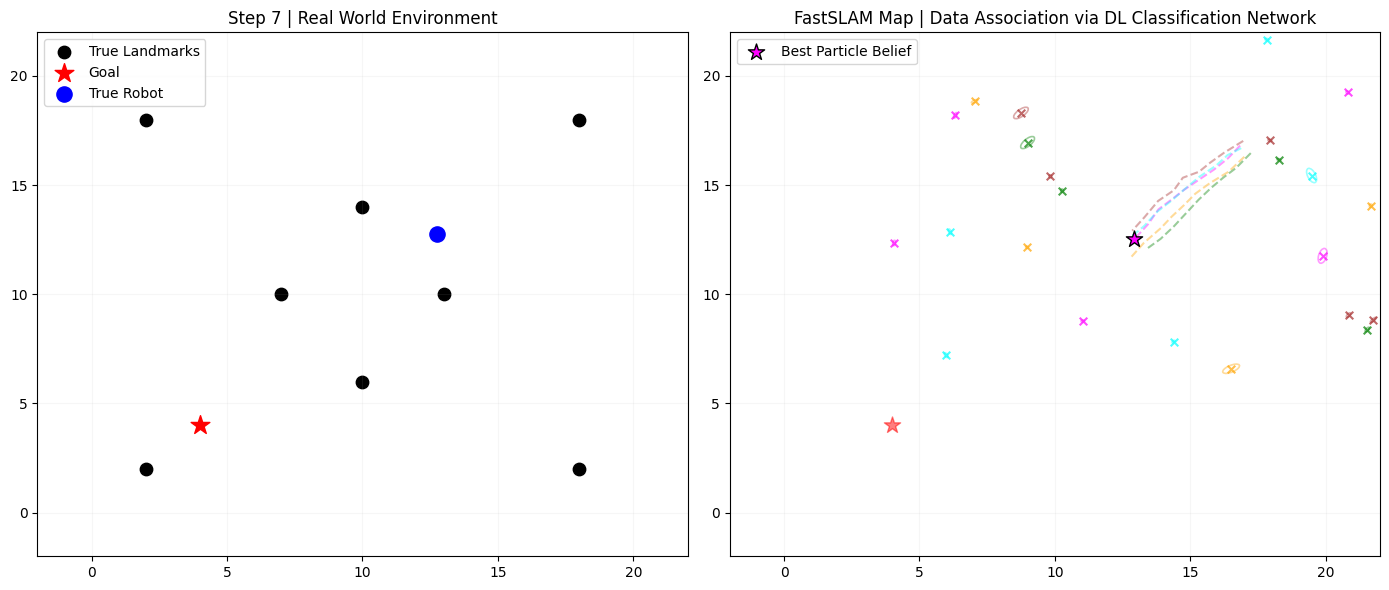


=================== STEP 08 ===================
True Robot Position: [12.20, 12.25]
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Dete

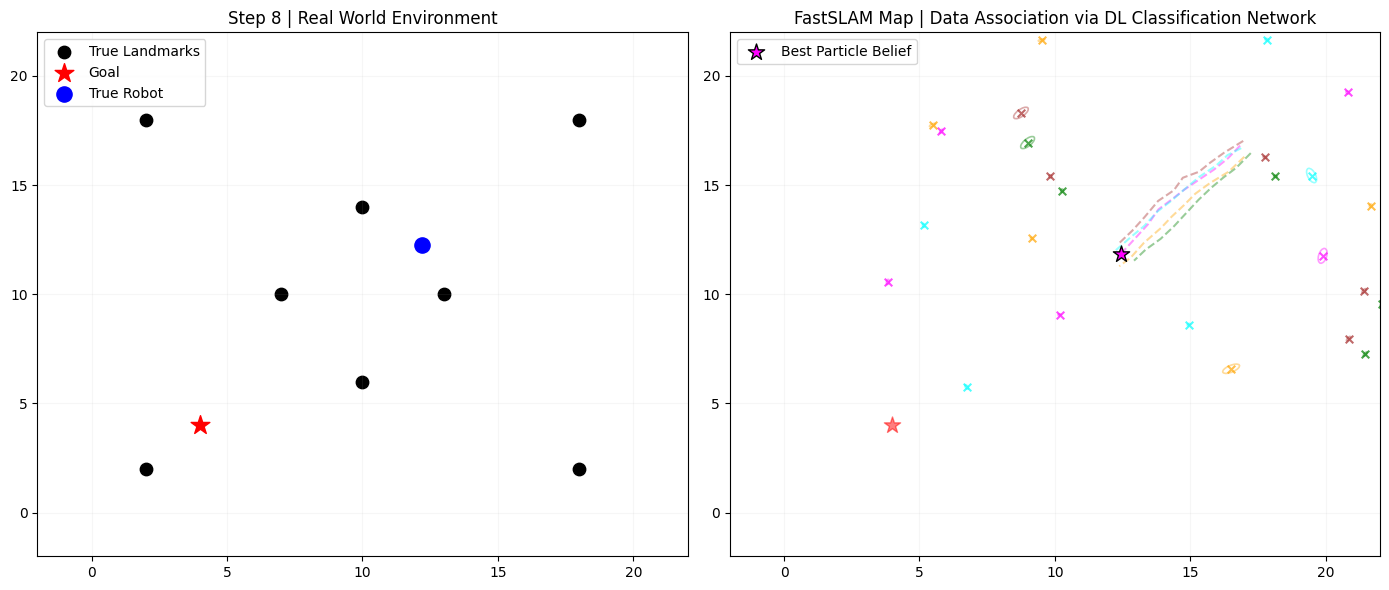


=================== STEP 09 ===================
True Robot Position: [11.65, 11.74]
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Dete

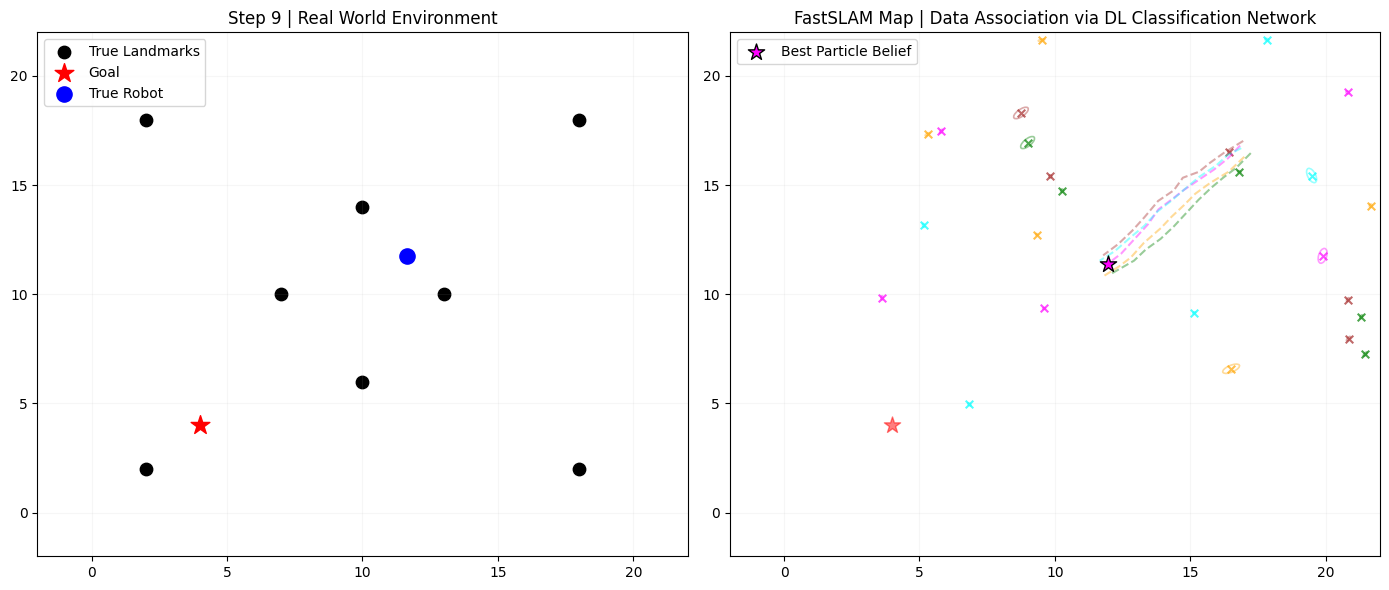


=================== STEP 10 ===================
True Robot Position: [11.10, 11.23]
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 3
    ↳ Particle 0 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 3 (Updated existing map entry)
  [Measurement Dete

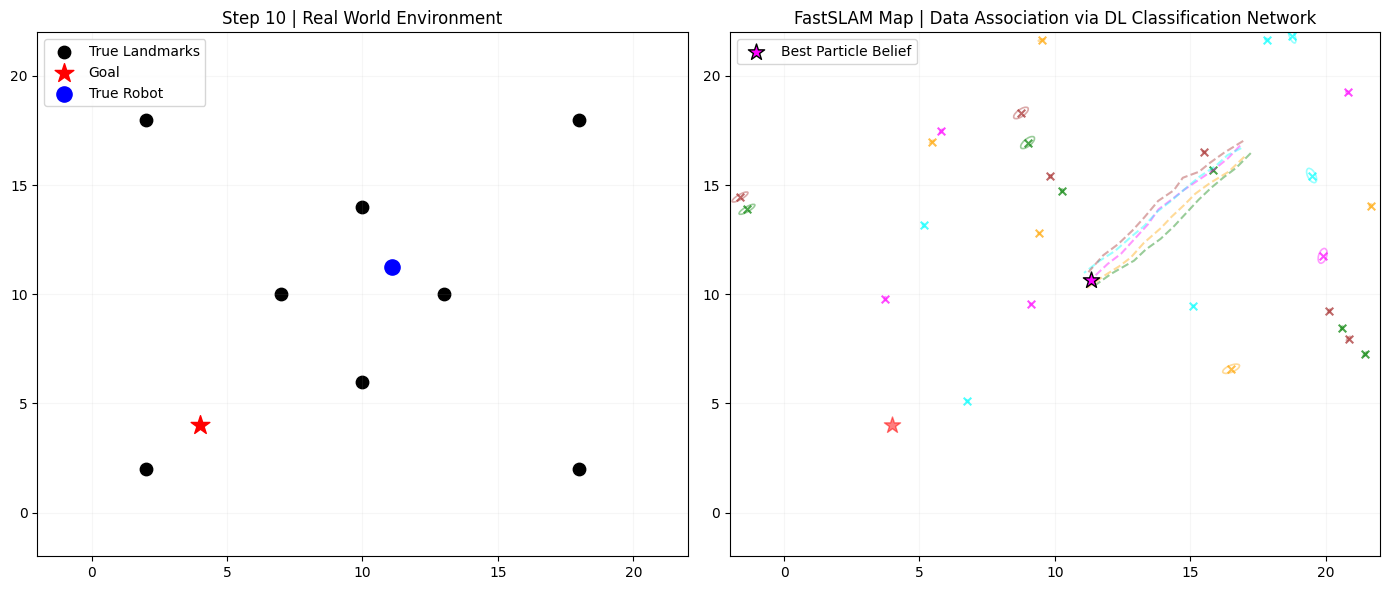


=================== STEP 11 ===================
True Robot Position: [10.55, 10.73]
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 2
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Dete

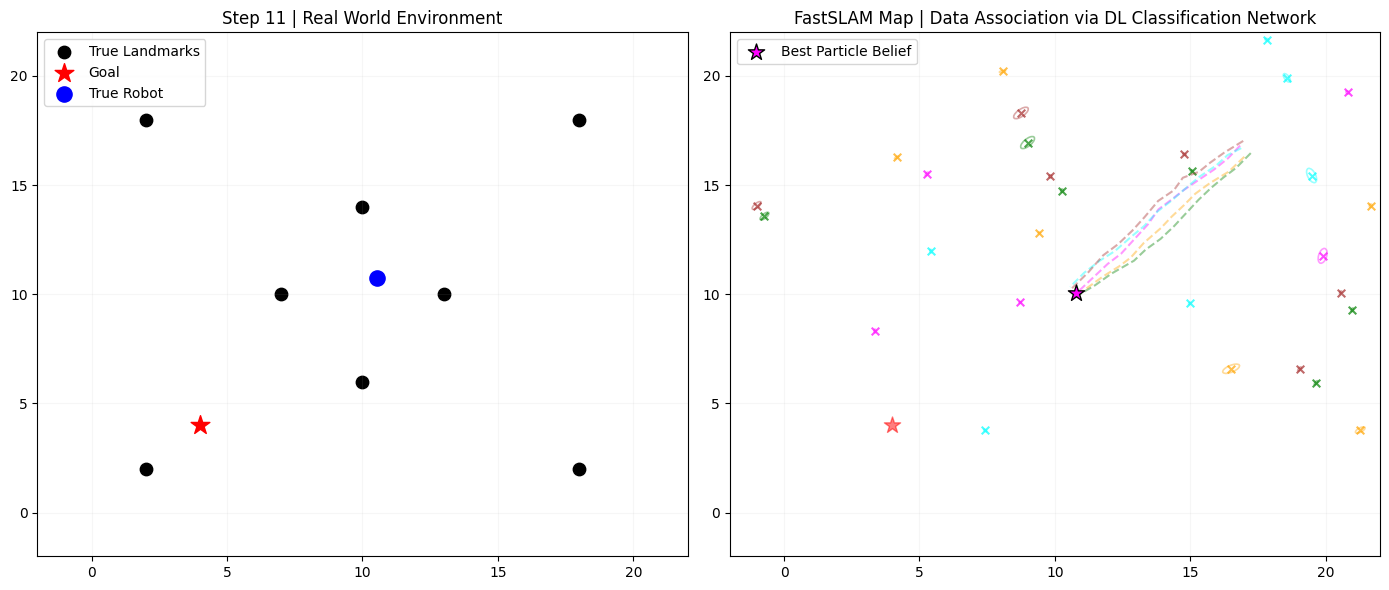


=================== STEP 12 ===================
True Robot Position: [9.99, 10.23]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detec

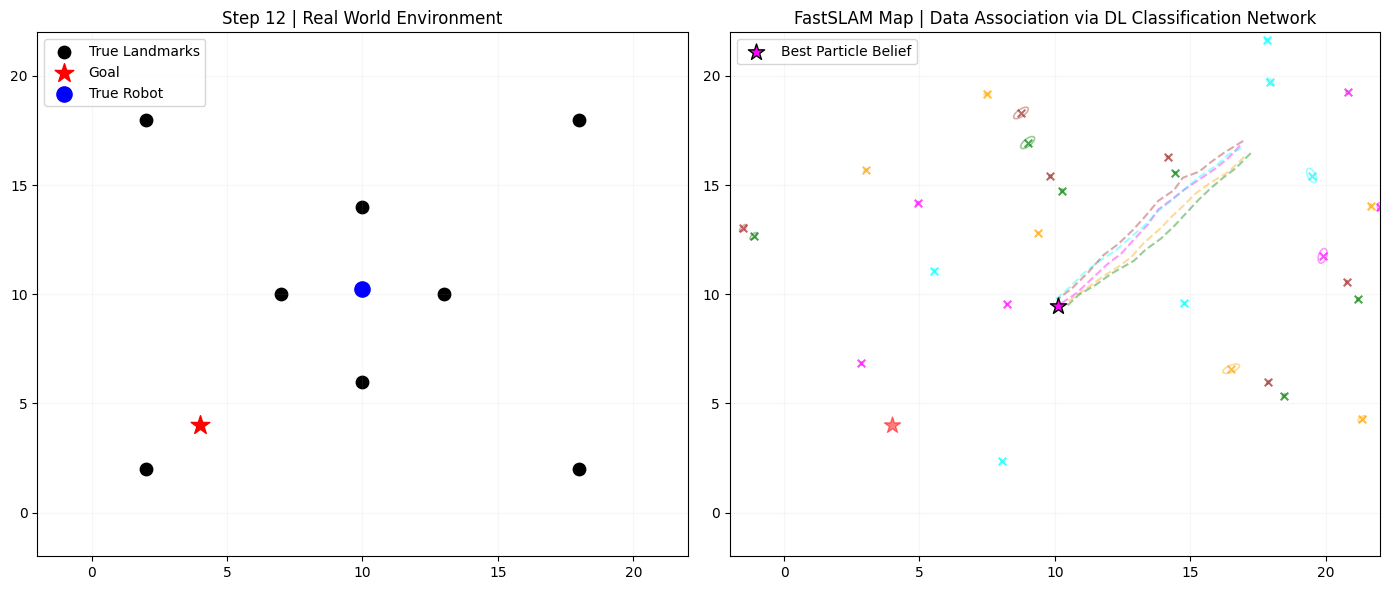


=================== STEP 13 ===================
True Robot Position: [9.43, 9.73]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 6
    ↳ Particle 0 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 6 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 6 (Updated existing map entry)
  [Measurement Detect

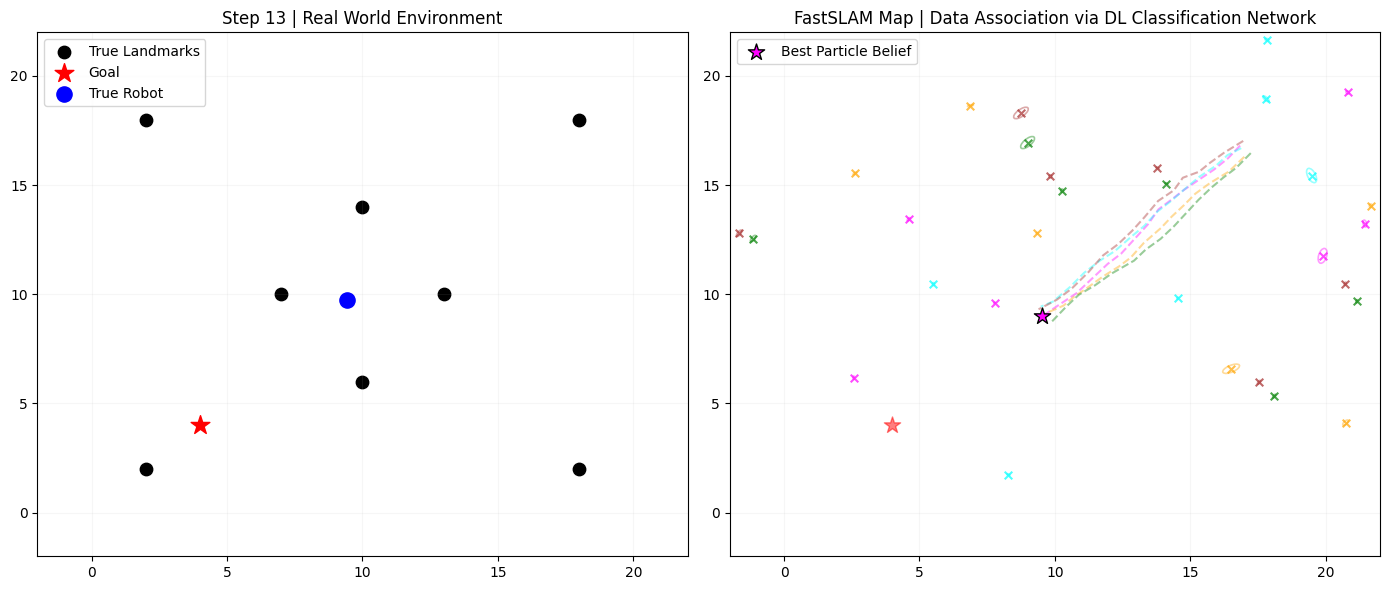


=================== STEP 14 ===================
True Robot Position: [8.88, 9.22]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 3
    ↳ Particle 0 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 3 (Updated existing map entry)
  [Measurement Detect

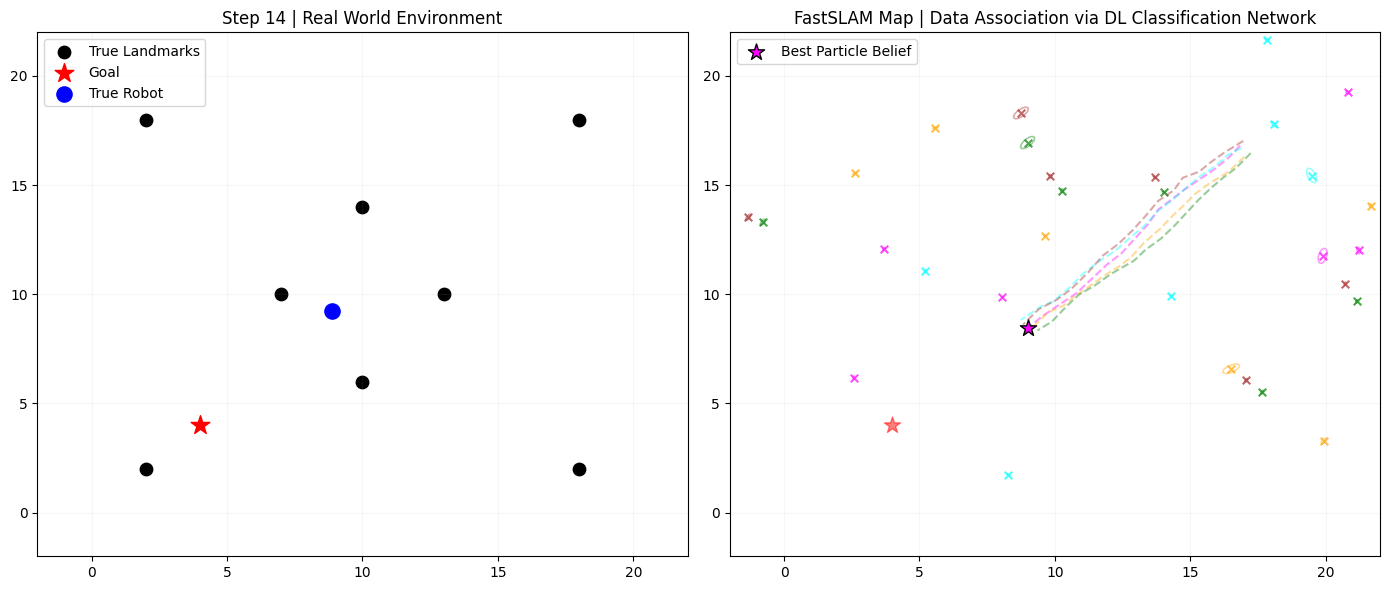


=================== STEP 15 ===================
True Robot Position: [8.31, 8.72]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 1
                         -> Neural Network Resolved ID: 1
    ↳ Particle 0 updated Landmark ID 1 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 1 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 1 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 1 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 1 (Updated existing map entry)
  [Measurement Detect

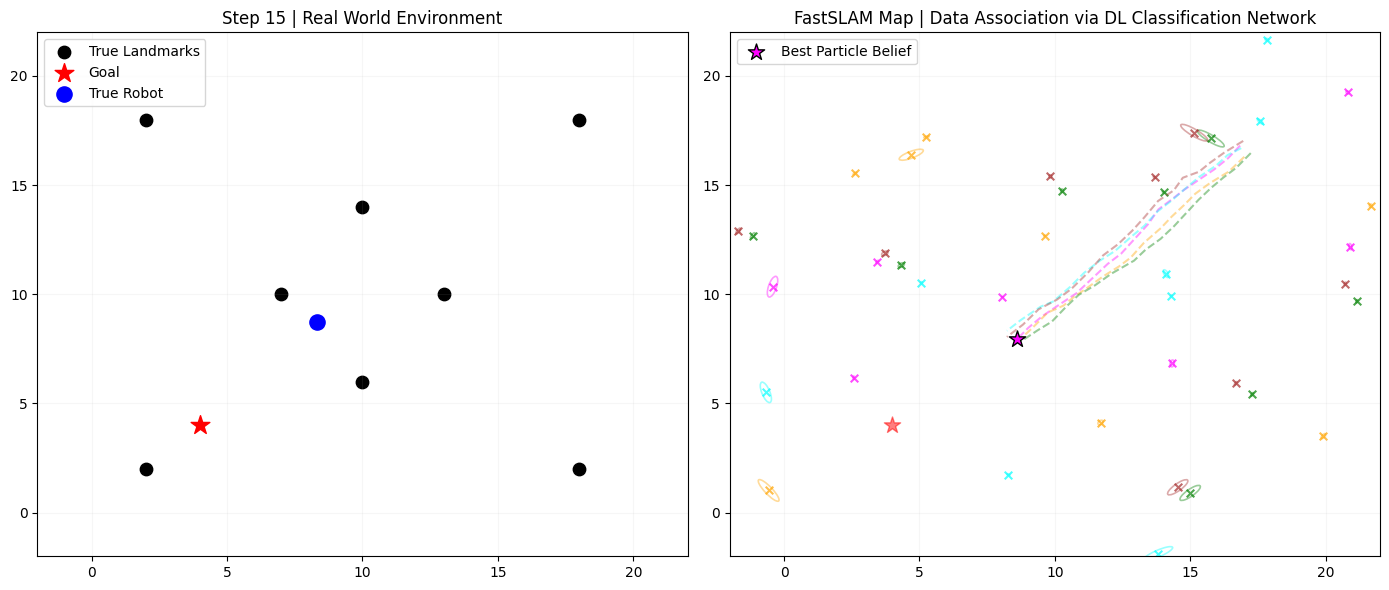


=================== STEP 16 ===================
True Robot Position: [7.75, 8.24]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 3
                         -> Neural Network Resolved ID: 3
    ↳ Particle 0 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 3 (Updated existing map entry)
  [Measurement Detect

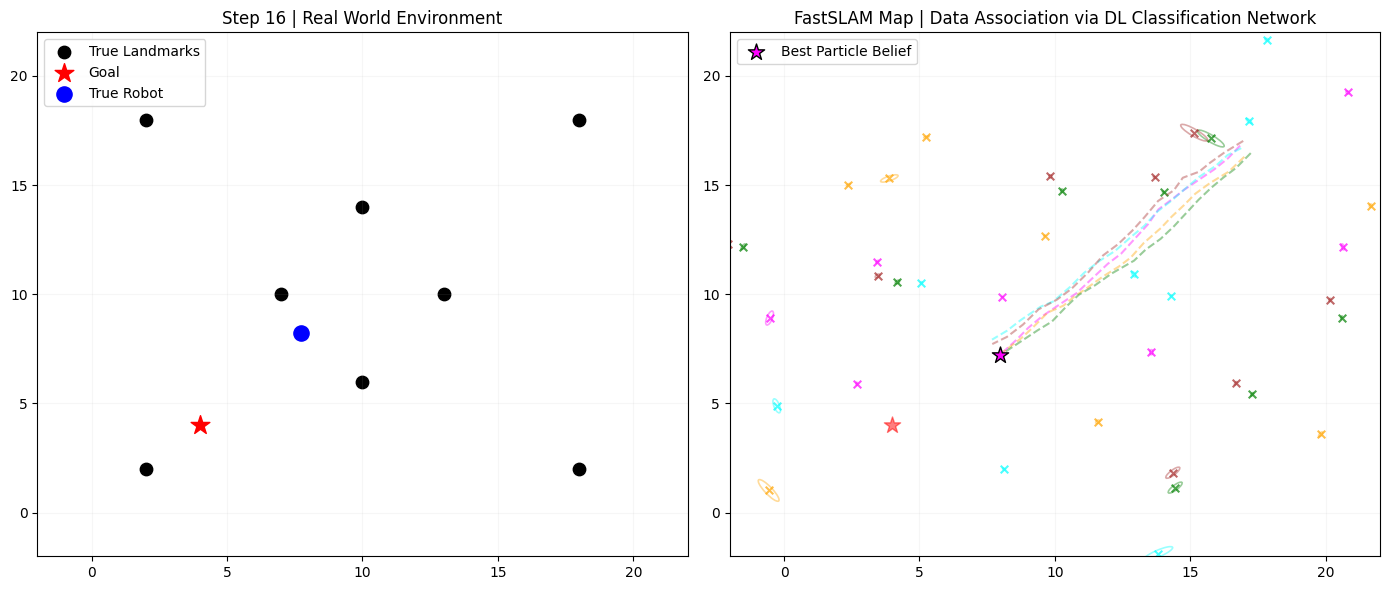


=================== STEP 17 ===================
True Robot Position: [7.16, 7.76]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 3
                         -> Neural Network Resolved ID: 3
    ↳ Particle 0 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 3 (Updated existing map entry)
  [Measurement Detect

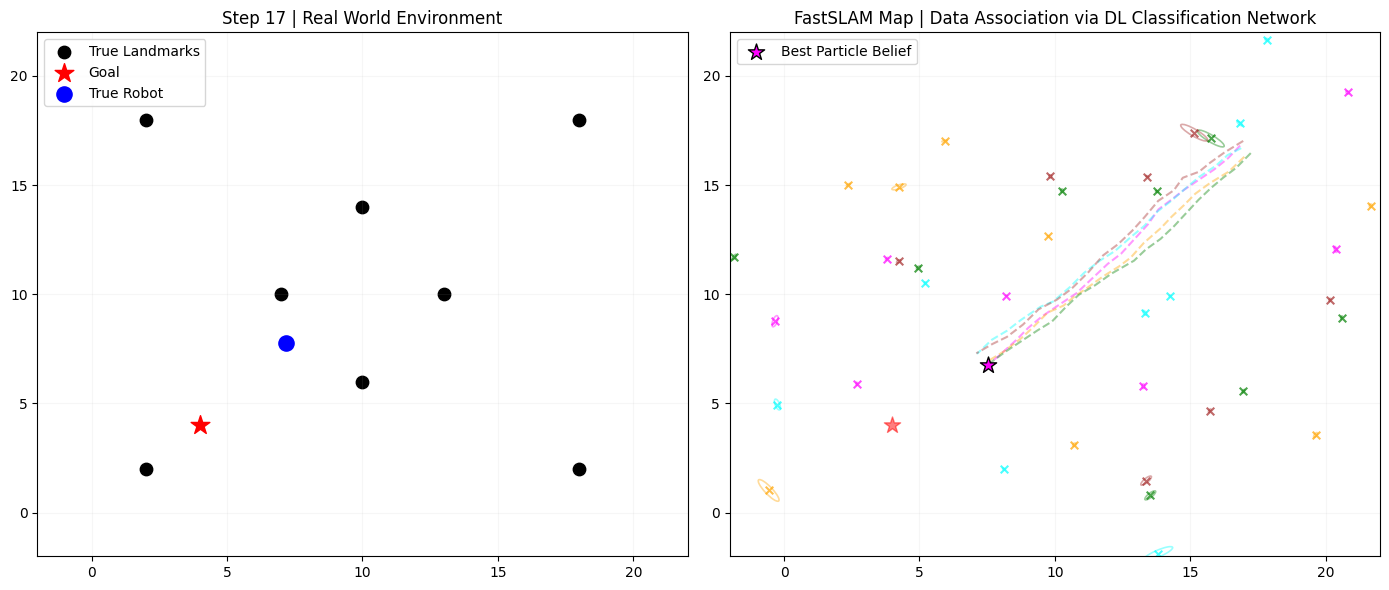


=================== STEP 18 ===================
True Robot Position: [6.57, 7.30]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 3
                         -> Neural Network Resolved ID: 3
    ↳ Particle 0 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 3 (Updated existing map entry)
  [Measurement Detect

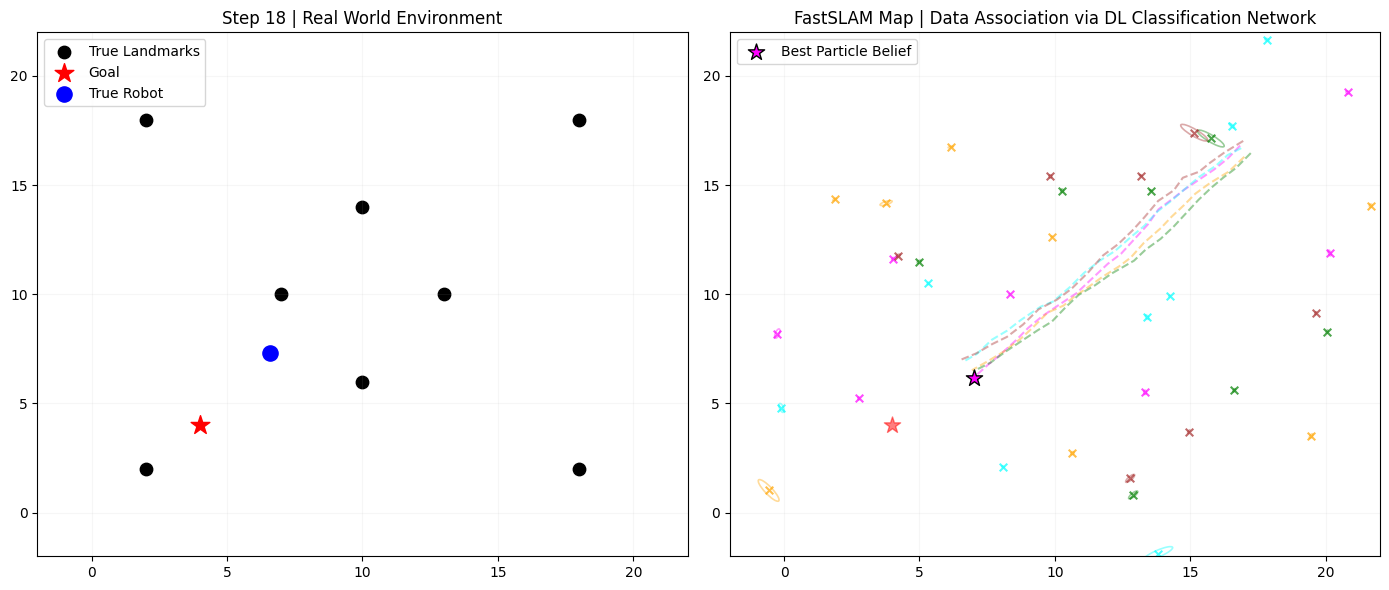


=================== STEP 19 ===================
True Robot Position: [5.97, 6.86]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 3
                         -> Neural Network Resolved ID: 3
    ↳ Particle 0 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 3 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 3 (Updated existing map entry)
  [Measurement Detect

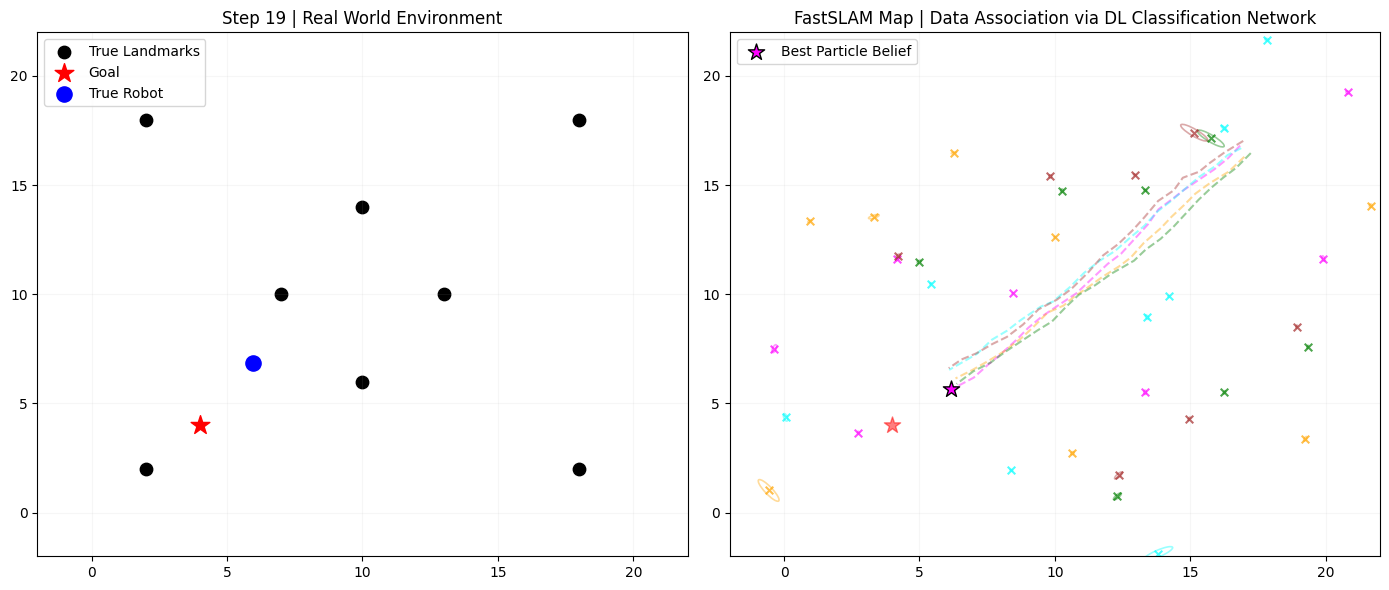


=================== STEP 20 ===================
True Robot Position: [5.37, 6.41]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Detect

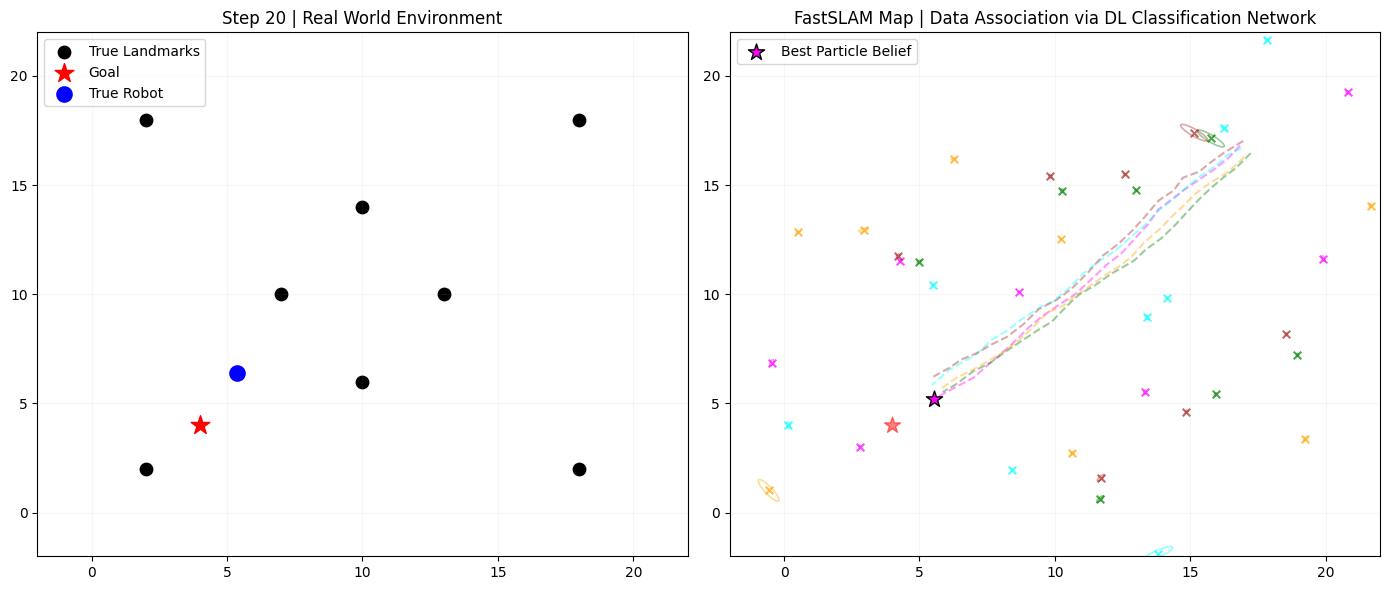


=================== STEP 21 ===================
True Robot Position: [4.78, 5.94]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Detect

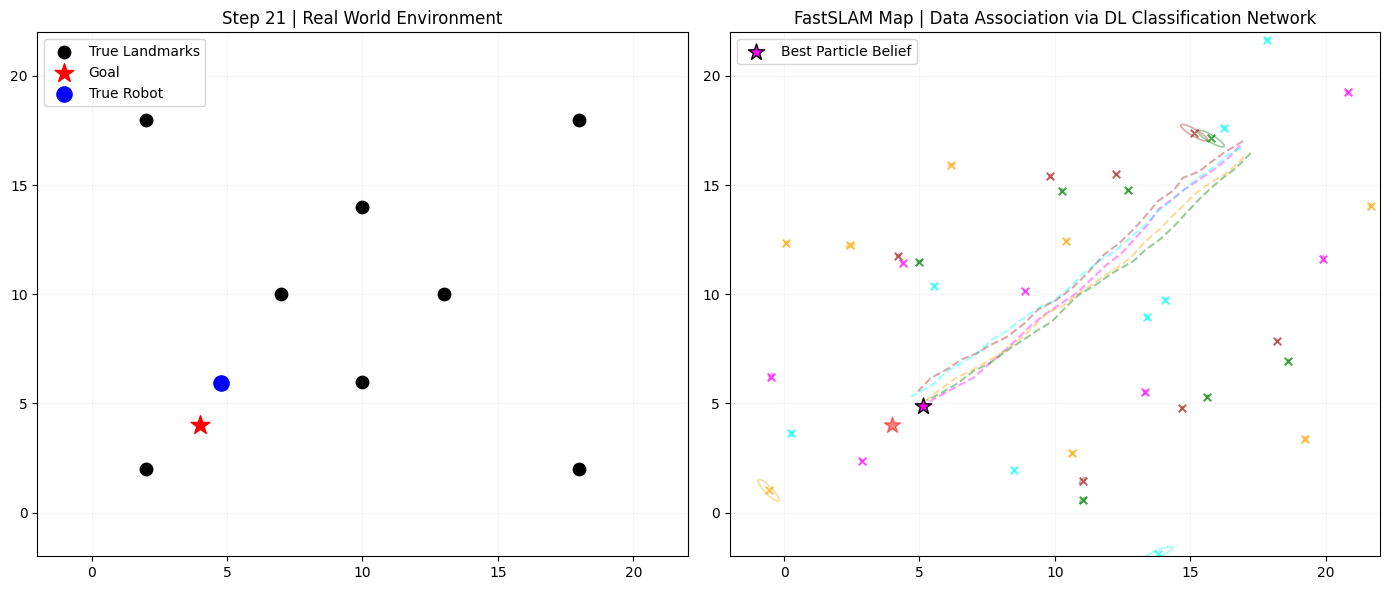


=================== STEP 22 ===================
True Robot Position: [4.18, 5.49]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Detect

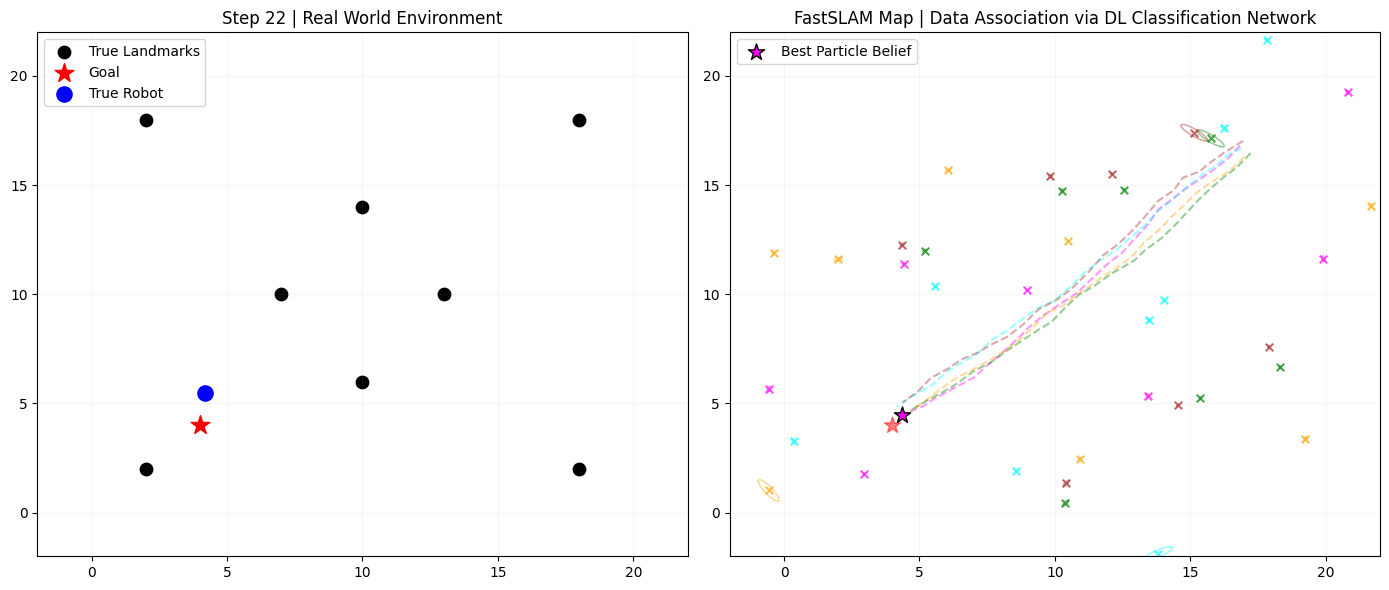


=================== STEP 23 ===================
True Robot Position: [3.74, 4.88]
  [Measurement Detected] -> Actual Landmark ID: 0
                         -> Neural Network Resolved ID: 0
    ↳ Particle 0 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 0 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 0 (Updated existing map entry)
  [Measurement Detected] -> Actual Landmark ID: 4
                         -> Neural Network Resolved ID: 4
    ↳ Particle 0 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 1 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 2 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 3 updated Landmark ID 4 (Updated existing map entry)
    ↳ Particle 4 updated Landmark ID 4 (Updated existing map entry)
  [Measurement Detect

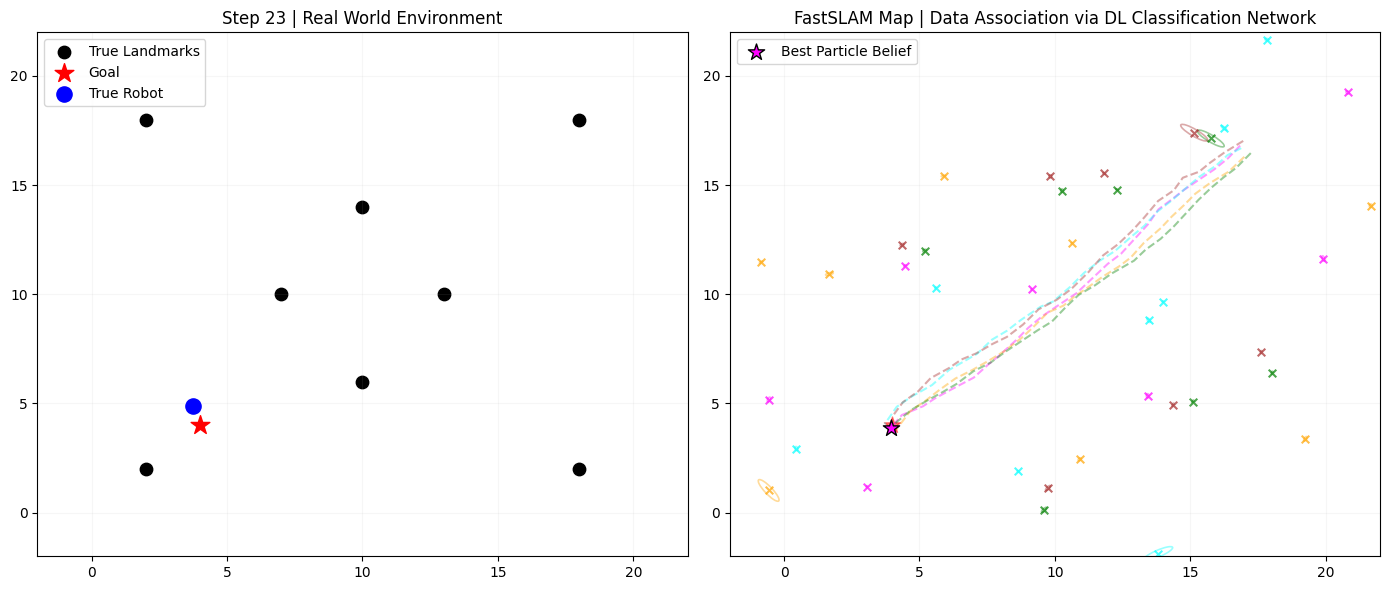

Goal reached at step 24!


In [ ]:
def run_simulation():
    env = WarehouseEnv()


    da_net = DataAssociationNet(input_dim=5, num_classes=NUM_LANDMARKS)
    optimizer = optim.Adam(da_net.parameters(), lr=0.01)
    loss_criterion = nn.CrossEntropyLoss()

    particles = [FastSLAMParticle() for _ in range(NUM_PARTICLES)]
    particle_colors = ['magenta', 'cyan', 'orange', 'green', 'brown']

    for step in range(25):
        best_p = particles[np.argmax([p.weight for p in particles])]

        # Goal Navigation Action: Proportional geometric controller heading straight to goal
        goal_vector = FIXED_GOAL - best_p.x[:2]
        dist = np.linalg.norm(goal_vector)
        if dist < 0.5:
            print(f"Goal reached at step {step}!")
            break
        u = (goal_vector / dist) * 0.75  # Step size speed velocity limit

        # Environment physics step
        true_pos, raw_obs = env.step(u)


        for p in particles:
            p.predict(u)

        print(f"\n=================== STEP {step:02d} ===================")
        print(f"True Robot Position: [{true_pos[0]:.2f}, {true_pos[1]:.2f}]")


        for true_id, z in raw_obs:

            feat_in = torch.FloatTensor([best_p.x[0], best_p.x[1], best_p.x[2], z[0], z[1]])


            da_scores = da_net(feat_in.unsqueeze(0))
            predicted_id = da_scores.argmax(dim=1).item()


            print(f"  [Measurement Detected] -> Actual Landmark ID: {true_id}")
            print(f"                         -> Neural Network Resolved ID: {predicted_id}")

            # Online Supervised Training step (Simulating local ground truth validation over time)
            target_tensor = torch.LongTensor([true_id])
            loss = loss_criterion(da_scores, target_tensor)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Apply the DL predicted index ID directly to update all EKF internal filters
            for p_idx, p in enumerate(particles):
                p.update(predicted_id, z)
                status = "Updated existing map entry" if p.lm_observed[predicted_id] else "Initialized brand new map entry"
                print(f"    ↳ Particle {p_idx} updated Landmark ID {predicted_id} ({status})")

        # Resampling Logic
        weights = np.array([p.weight for p in particles]) + 1e-9
        weights /= np.sum(weights)
        indices = []
        r = random.uniform(0, 1.0 / NUM_PARTICLES)
        c = weights[0]
        i = 0
        for m in range(NUM_PARTICLES):
            u_val = r + m * (1.0 / NUM_PARTICLES)
            while u_val > c and i < NUM_PARTICLES - 1:
                i += 1
                c += weights[i]
            indices.append(i)

        new_particles = []
        for idx in indices:
            np_part = FastSLAMParticle()
            np_part.x = particles[idx].x.copy()
            np_part.history = list(particles[idx].history)
            np_part.lm_means = particles[idx].lm_means.copy()
            np_part.lm_covs = particles[idx].lm_covs.copy()
            np_part.lm_observed = particles[idx].lm_observed.copy()
            new_particles.append(np_part)
        particles = new_particles


        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        for ax in [ax1, ax2]:
            ax.set_xlim(-2, GRID_SIZE + 2)
            ax.set_ylim(-2, GRID_SIZE + 2)
            ax.grid(True, alpha=0.1)

        ax1.set_title(f"Step {step} | Real World Environment")
        ax1.scatter(LANDMARKS[:, 0], LANDMARKS[:, 1], color='black', s=80, label='True Landmarks')
        ax1.scatter(FIXED_GOAL[0], FIXED_GOAL[1], color='red', marker='*', s=200, label='Goal')
        ax1.scatter(true_pos[0], true_pos[1], color='blue', s=120, label='True Robot', zorder=5)
        ax1.legend(loc='upper left')

        ax2.set_title("FastSLAM Map | Data Association via DL Classification Network")
        ax2.scatter(FIXED_GOAL[0], FIXED_GOAL[1], color='red', marker='*', s=150, alpha=0.5)

        for p_idx, p in enumerate(particles):
            p_color = particle_colors[p_idx % len(particle_colors)]
            hist = np.array(p.history)
            ax2.plot(hist[:, 0], hist[:, 1], linestyle='--', alpha=0.4, color=p_color)

            for l_idx in range(NUM_LANDMARKS):
                if p.lm_observed[l_idx]:
                    m = p.lm_means[l_idx]
                    ax2.scatter(m[0], m[1], marker='x', s=30, color=p_color, alpha=0.7)
                    draw_covariance_ellipse(ax2, m, p.lm_covs[l_idx], color=p_color)

        best_p = particles[np.argmax([p.weight for p in particles])]
        ax2.scatter(best_p.x[0], best_p.x[1], marker='*', s=150, color='magenta', edgecolor='black', label='Best Particle Belief', zorder=10)
        ax2.legend(loc='upper left')

        plt.tight_layout()
        plt.show()

run_simulation()